# **Real** vs **Fake** face detection using Keras

This project aims to discriminate between **fake** images and **real** ones. This dataset consists of all 70k REAL faces from the Flickr dataset collected by Nvidia, as well as 70k fake faces sampled from the 1 Million FAKE faces (generated by StyleGAN) that was provided by Bojan.

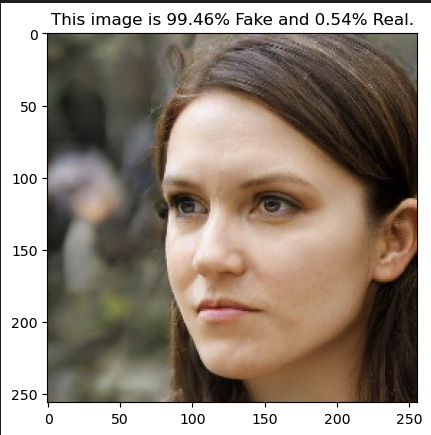

The project will include also the **Grad-cam** visualization to understand why a deep learning network makes its classification decisions.

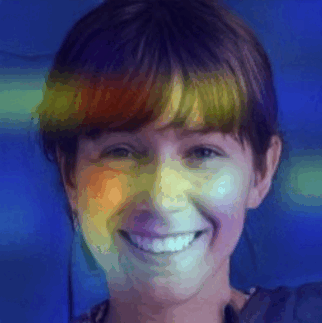

# Main Libraries

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import glob
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.models import load_model
from keras.preprocessing import image
import seaborn as sns
from sklearn import metrics



# pip install tensorflow

KeyboardInterrupt: 

In [ ]:
import sys
# 현재 연결된 파이썬 경로에 직접 텐서플로를 설치합니다.
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow

In [ ]:
tf.keras.backend.clear_session() #clean session

# Data Loading

The paths to the training, validation, and test sets have been specified below.

In [ ]:
main_path = './data/sample'

train_dir = os.path.join(main_path, 'train')
valid_dir = os.path.join(main_path, 'valid')
test_dir = os.path.join(main_path, 'test')

As we can see, each directory contains two subfolders: fake and real.

In [ ]:
print("Train_dir Subfolders: ", os.listdir(train_dir))
print("Valid_dir Subfolders: ", os.listdir(valid_dir))
print("Test_dir Subfolders: ", os.listdir(test_dir))

Train_dir Subfolders:  ['fake', 'real']
Valid_dir Subfolders:  ['fake', 'real']
Test_dir Subfolders:  ['fake', 'real']


# Short EDA - Exploratory Data Analysis

Create a dictionary with three keys:
* **folder**: train, validation and test folders
* **image_path**: path of the images
* **label**: image's label (fake or real)    

In [ ]:
images_df = {
    "folder":[],
    "image_path":[],
    "label":[]
}

for folder in os.listdir(main_path): #iterate on each train, valid and test folder
    for label in os.listdir(main_path + "/" + folder): #iterate on fake and real folders (labels)
        for img in glob.glob(main_path + "/" + folder + "/" + label + "/*.jpg"):
            images_df["folder"].append(folder)
            images_df["image_path"].append(img)
            images_df["label"].append(label)

In [ ]:
images_df = pd.DataFrame(images_df)

In [ ]:
images_df

,folder,image_path,label
0,test,./data/sample/test/fake\SDXL_image_0000902.jpg,fake
1,test,./data/sample/test/fake\SDXL_image_0000903.jpg,fake
2,test,./data/sample/test/fake\SDXL_image_0000904.jpg,fake
3,test,./data/sample/test/fake\SDXL_image_0000905.jpg,fake
4,test,./data/sample/test/fake\SDXL_image_0000906.jpg,fake
...,...,...,...
1995,valid,./data/sample/valid/real\00895.jpg,real
1996,valid,./data/sample/valid/real\00896.jpg,real
1997,valid,./data/sample/valid/real\00897.jpg,real
1998,valid,./data/sample/valid/real\00898.jpg,real


### Labels distribution

In [ ]:
real_grouped_df = images_df[images_df['label'] == "real"].groupby('folder')
fake_grouped_df = images_df[images_df['label'] == "fake"].groupby('folder')

In [ ]:
real_grouped_df.size()

folder
test     100
train    800
valid    100
dtype: int64

In [ ]:
fake_grouped_df.size()

folder
test     100
train    800
valid    100
dtype: int64

As we can see fromt the results, the labels are equally distributed on each folder.

# Data Preparation for visualization and training

## Data Augmentation

ImageDataGenerator generates batches of tensor image data with real-time data augmentation. Horizontal flip data augmentation is set to True in order to increase the size of a dataset by flipping images horizontally. This can help improve the accuracy of the model by exposing it to additional variations of the same images.

In [ ]:
image_train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
                                  rescale=1./255.,
                                  horizontal_flip=True,
                                  )

image_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255.)

Important! test_ds prediction and train_ds.classes (ground-truth) **will be not alligned** with suffle=True, so I need to disable shuffle for the test set.

In [ ]:
train_ds = image_train_gen.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=64,
    class_mode='binary',
)

valid_ds = image_gen.flow_from_directory(
    valid_dir,
    target_size=(256, 256),
    batch_size=64,
    class_mode='binary'
)

test_ds = image_gen.flow_from_directory(
    test_dir,
    target_size=(256, 256),
    batch_size=64,
    class_mode='binary',
    shuffle=False) #shuffle disabled

Found 1600 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [ ]:
def plot_images(img, label):
    plt.figure(figsize=[12, 12])
    for i in range(16):
        plt.subplot(4, 4, i+1)
        plt.imshow(img[i])
        plt.axis('off')
        if label[i] == 0:
            plt.title("Fake")
        else:
            plt.title("Real")

# Data Visualization

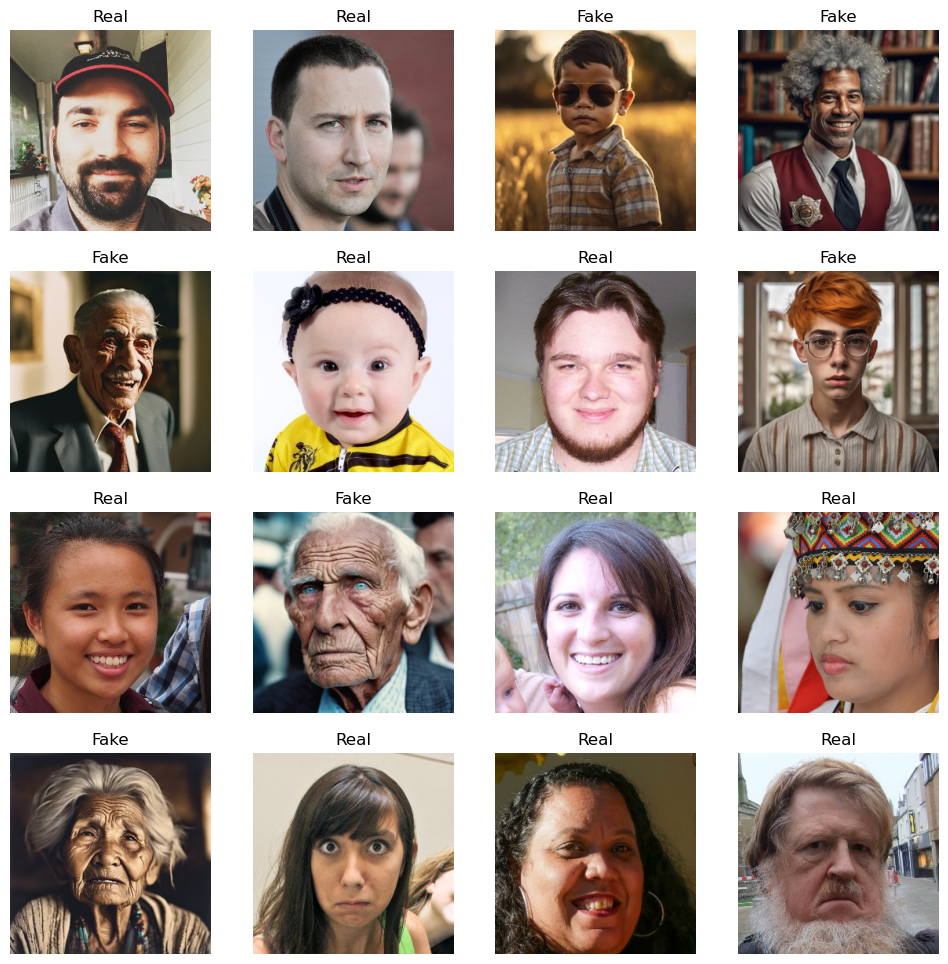

In [ ]:
img,lbl = next(train_ds)
plot_images(img,lbl)


It's visible that all the value are scaled.

In [ ]:
for img, label in train_ds:
    print("Values: ", img[0])
    print("Label: ", label[0])
    break

Values:  [[[0.18823531 0.13333334 0.08235294]
  [0.1764706  0.12156864 0.07058824]
  [0.16470589 0.10980393 0.05882353]
  ...
  [0.8235295  0.7254902  0.6039216 ]
  [0.8196079  0.72156864 0.6       ]
  [0.8196079  0.72156864 0.6       ]]

 [[0.18823531 0.13333334 0.08235294]
  [0.18039216 0.1254902  0.07450981]
  [0.16862746 0.1137255  0.0627451 ]
  ...
  [0.8235295  0.7254902  0.6039216 ]
  [0.8235295  0.7254902  0.6039216 ]
  [0.8196079  0.72156864 0.6       ]]

 [[0.18823531 0.13333334 0.08235294]
  [0.18039216 0.1254902  0.07450981]
  [0.17254902 0.11764707 0.06666667]
  ...
  [0.82745105 0.7294118  0.60784316]
  [0.82745105 0.7294118  0.60784316]
  [0.82745105 0.7294118  0.60784316]]

 ...

 [[0.43529415 0.40784317 0.36862746]
  [0.4431373  0.4156863  0.37647063]
  [0.42352945 0.39607847 0.35686275]
  ...
  [0.49803925 0.46274513 0.427451  ]
  [0.5058824  0.47058827 0.43529415]
  [0.5647059  0.5294118  0.49411768]]

 [[0.43921572 0.41176474 0.37254903]
  [0.44705886 0.41960788 0.3

Let's print the input shape:
- 32 is the batch size
- 256s are the pixel's values.
- 3 are the channel (rgb)

In [ ]:
for img, label in train_ds:
    print(img.shape)
    print(label.shape)
    break

(64, 256, 256, 3)
(64,)


In [ ]:
train_ds.class_indices

{'fake': 0, 'real': 1}

# CNN model architecture (DenseNet121)

In [ ]:
input_shape = (256, 256, 3) #define the input shape of our data

In [ ]:
#create the model's architecture and compile it
def get_model(input_shape):

    input = tf.keras.Input(shape=input_shape)

    densenet = tf.keras.applications.DenseNet121( weights="imagenet", include_top=False, input_tensor = input)

    x = tf.keras.layers.GlobalAveragePooling2D()(densenet.output)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x) #binary classification

    model = tf.keras.Model(densenet.input, output)

    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

    return model


In [ ]:
model_ft = get_model(input_shape)

model_ft.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 262, 262,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 64, 64,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 64, 64,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 64, 64,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 64, 64,    │     12,288 │ conv2_block2_0_r

 Total params: 7,564,865 (28.86 MB)

 Trainable params: 7,480,193 (28.53 MB)

 Non-trainable params: 84,672 (330.75 KB)

In [ ]:
tf.keras.utils.plot_model(model_ft, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


Let's define the Callbacks

ModelCheckpoint 콜백은 model.fit()을 사용한 학습 과정과 함께 사용되며, 일정한 간격마다 모델 또는 가중치를 체크포인트 파일로 저장하는 역할을 한다. 이렇게 저장된 모델이나 가중치는 나중에 다시 불러와서 저장된 상태부터 학습을 이어서 진행할 수 있다.

이 경우에는 학습이 너무 오래 진행되어 훈련 데이터셋에 과적합되는 문제를 걱정하지 않아도 된다.

In [ ]:
checkpoint_filepath = "model_cp.weights.h5"

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True
)

The **EarlyStopping** callback stops training when a monitored metric (in this case val_loss) has stopped improving (in this case decreasing).

In [ ]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                     patience=5,
                                                     restore_best_weights=True,
                                                    )

**ReduceOnPlateau** callback reduces learning rate when a metric has stopped improving. Models often benefit from reducing the learning rate by a factor of 2-10 once learning stagnates. This callback monitors a quantity and if no improvement is seen for a 'patience' number of epochs, the learning rate is reduced.

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                 factor=0.2,
                                                 patience=3)

# Training

In [ ]:
history_ft = model_ft.fit(train_ds,
                       epochs = 10,
                       validation_data = valid_ds,
                       callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 380s 14s/step - accuracy: 0.9613 - loss: 0.0917 - val_accuracy: 0.5450 - val_loss: 1.1982 - learning_rate: 0.0010
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 336s 13s/step - accuracy: 0.9919 - loss: 0.0258 - val_accuracy: 0.5000 - val_loss: 26.3959 - learning_rate: 0.0010
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 334s 13s/step - accuracy: 0.9956 - loss: 0.0112 - val_accuracy: 0.9150 - val_loss: 0.8020 - learning_rate: 0.0010
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 331s 13s/step - accuracy: 0.9975 - loss: 0.0068 - val_accuracy: 0.7650 - val_loss: 2.0133 - learning_rate: 0.0010
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 333s 13s/step - accuracy: 0.9881 - loss: 0.0307 - val_accuracy: 0.9150 - val_loss: 0.6974 - learning_rate: 0.0010
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 329s 13s/step - accuracy: 0.9925 - loss: 0.0176 - val_accuracy: 0.9750 - val_loss: 0.0990 - learning_rate: 0.0010
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 332s 13s/step - accuracy: 0.9975 - loss: 0.0093 -

# Results

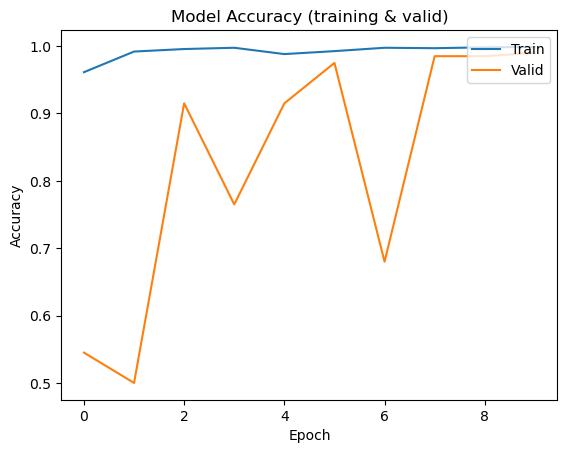

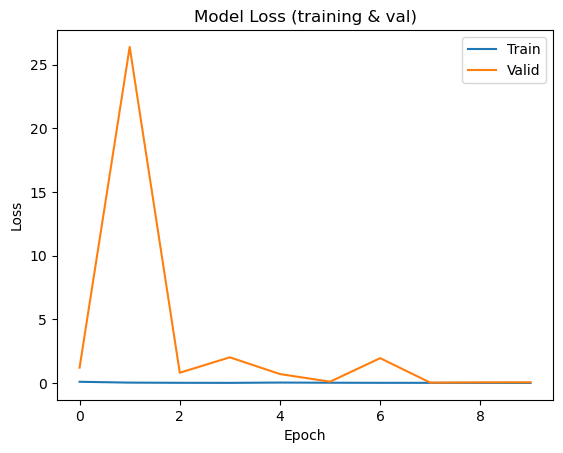

In [ ]:
plt.plot(history_ft.history['accuracy'])
plt.plot(history_ft.history['val_accuracy'])
plt.title('Model Accuracy (training & valid)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Valid'], loc='upper right')
plt.show()


plt.plot(history_ft.history['loss'])
plt.plot(history_ft.history['val_loss'])
plt.title('Model Loss (training & val)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Valid'], loc='upper right')
plt.show()

The model is clearly overfitted. So wee have to restore the model weights from the ModelCheckpoint callback.

Let's try to evaluate the full overfitted model. We can see that it has a poor performance.

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model_ft.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9950 - loss: 0.0146
Test Loss: 0.014567196369171143
Test Accuracy: 0.9950000047683716


Here a ModelCheckpoint callback is necessary. Indeed loading the best weights results in a much better performance on the test set.
여기서는 ModelCheckpoint 콜백이 필요하다. 실제로 가장 좋은 가중치를 불러오면 테스트 세트에서 훨씬 더 좋은 성능을 얻을 수 있다.

In [ ]:

model = get_model(input_shape)

# VS Code에서는 Colab drive mount 코드 삭제
# 체크포인트 파일이 현재 폴더에 있다면:
model.load_weights("model_cp.weights.h5")

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)



c:\Users\user\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 738 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9950 - loss: 0.0146
Test Loss: 0.014567196369171143
Test Accuracy: 0.9950000047683716


# Image example - Qualitative results

Let's try the model on a real image. It is very confident (99.96%) that it is a real one.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


Text(0.5, 1.0, 'This image is 0.00% Fake and 100.00% Real.')

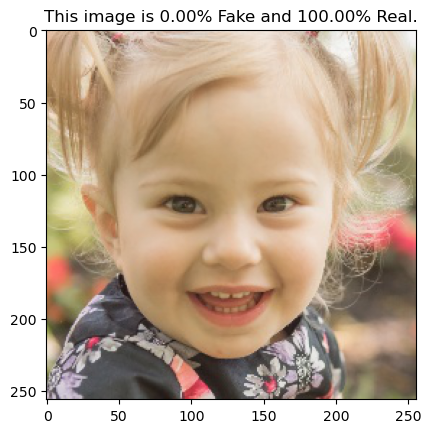

In [ ]:
#real example
test_image = tf.keras.preprocessing.image.load_img(r"C:\ai_image_detection\ai_image_detection\data\sample\test\real\00990.jpg", target_size=(256, 256))
plt.imshow(test_image)


test_image_arr = tf.keras.preprocessing.image.img_to_array(test_image)
test_image_arr = np.expand_dims(test_image_arr, axis=0)
test_image_arr = test_image_arr/255.


result = model.predict(test_image_arr)

plt.title(f"This image is {100 * (1 - result[0][0]):.2f}% Fake and {100 * result[0][0]:.2f}% Real.")


The result score is near 1 if the image is **real** and 0 if the image is **fake**.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


Text(0.5, 1.0, 'This image is 100.00% Fake and 0.00% Real.')

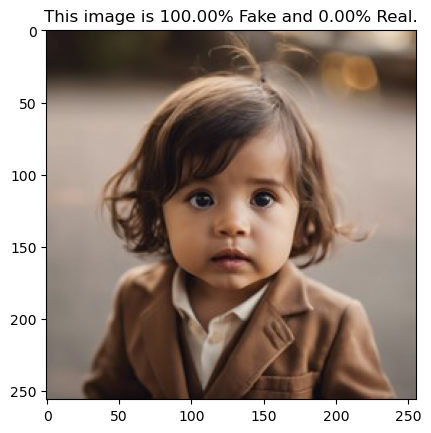

In [ ]:
test_image = tf.keras.preprocessing.image.load_img(r"C:\ai_image_detection\ai_image_detection\data\sample\test\fake\SDXL_image_0000998.jpg", target_size=(256, 256))
plt.imshow(test_image)

#fake example
test_image_arr = tf.keras.preprocessing.image.img_to_array(test_image)
test_image_arr = np.expand_dims(test_image_arr, axis=0)
test_image_arr = test_image_arr/255.


result = model.predict(test_image_arr)

plt.title(f"This image is {100 * (1 - result[0][0]):.2f}% Fake and {100 * result[0][0]:.2f}% Real.")

# Quantitative results

In [ ]:
# Assuming you have defined your model as 'model'
predicted_labels = model.predict(test_ds)

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step


In [ ]:
true_labels = test_ds.classes

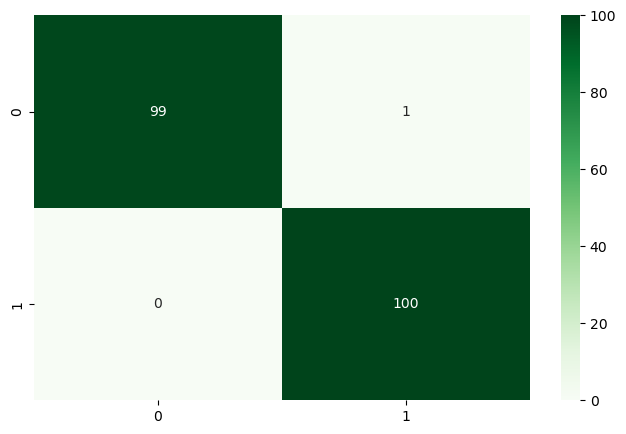

In [ ]:
plt.figure(figsize = (8,5))
sns.heatmap(metrics.confusion_matrix(true_labels, predicted_labels.round()), annot = True,fmt="d",cmap = "Greens")
plt.show()

In [ ]:
metrics.accuracy_score(true_labels, predicted_labels.round())

0.995

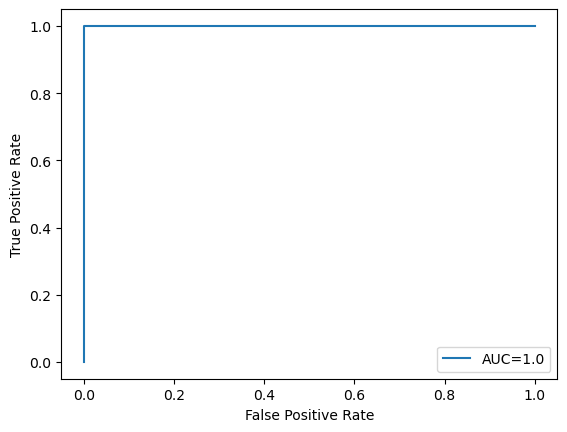

In [ ]:
fpr, tpr, _ = metrics.roc_curve(true_labels,  predicted_labels)
auc = metrics.roc_auc_score(true_labels, predicted_labels)

#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

# Grad-cam class activation visualization

This example shows how to use the gradient-weighted class activation mapping (Grad-CAM) technique to understand why a deep learning network makes its classification decisions. Grad-CAM, invented by Selvaraju and coauthors, uses the gradient of the classification score with respect to the convolutional features determined by the network in order to understand which parts of the image are most important for classification.

Lot of the following code is from https://keras.io/examples/vision/grad_cam/

In [ ]:
# Display
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import keras

In [ ]:
def get_img_array(img_path, size):
    # `img` is a PIL image of size 299x299
    img = keras.utils.load_img(img_path, target_size=size)
    # `array` is a float32 Numpy array of shape (299, 299, 3)
    array = keras.utils.img_to_array(img)
    # We add a dimension to transform our array into a "batch"
    # of size (1, 299, 299, 3)
    array = np.expand_dims(array, axis=0)
    return array


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [ ]:
def save_and_display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.5):
    # Load the original image
    img = keras.utils.load_img(img_path)
    img = keras.utils.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    # Save the superimposed image
    superimposed_img.save(cam_path)

    # Display Grad CAM
    display(Image(cam_path))

In [ ]:
# Get the names of all layers in the model.
for idx in range(len(model.layers)):
  print(model.get_layer(index = idx).name)

input_layer_4
zero_padding2d_8
conv1_conv
conv1_bn
conv1_relu
zero_padding2d_9
pool1
conv2_block1_0_bn
conv2_block1_0_relu
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_concat
conv2_block2_0_bn
conv2_block2_0_relu
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_concat
conv2_block3_0_bn
conv2_block3_0_relu
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_concat
conv2_block4_0_bn
conv2_block4_0_relu
conv2_block4_1_conv
conv2_block4_1_bn
conv2_block4_1_relu
conv2_block4_2_conv
conv2_block4_concat
conv2_block5_0_bn
conv2_block5_0_relu
conv2_block5_1_conv
conv2_block5_1_bn
conv2_block5_1_relu
conv2_block5_2_conv
conv2_block5_concat
conv2_block6_0_bn
conv2_block6_0_relu
conv2_block6_1_conv
conv2_block6_1_bn
conv2_block6_1_relu
conv2_block6_2_conv
conv2_block6_concat
pool2_bn
pool2_relu
pool2_conv
pool2_pool
conv3_block1_0_bn
conv3_block1_0_relu
conv3_block1_1_conv

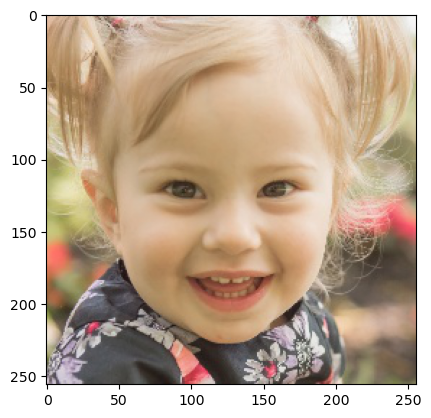

In [ ]:
img_size = (256, 256)

last_conv_layer_name = "conv5_block16_1_conv"

img_path = r"C:\ai_image_detection\ai_image_detection\data\sample\test\real\00990.jpg"

test_image = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=img_size
)

plt.imshow(test_image)

img = tf.keras.preprocessing.image.img_to_array(test_image)
img = np.expand_dims(img, axis=0)
img = img / 255.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted: [[1.]]


c:\Users\user\anaconda3\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1736']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


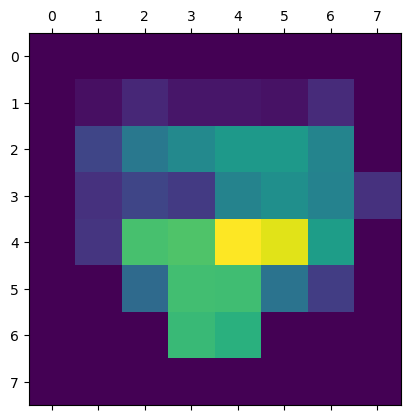

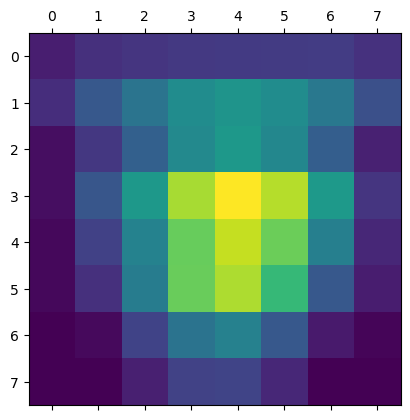

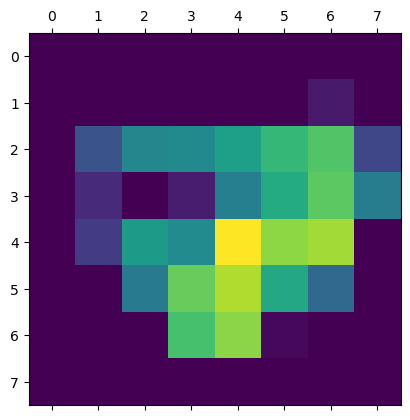

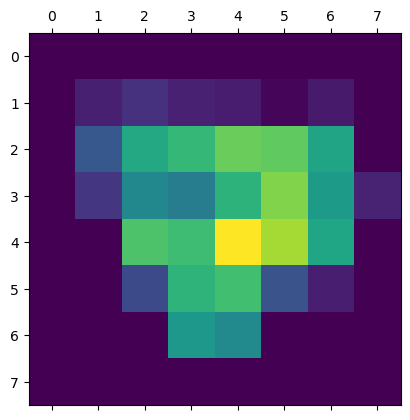

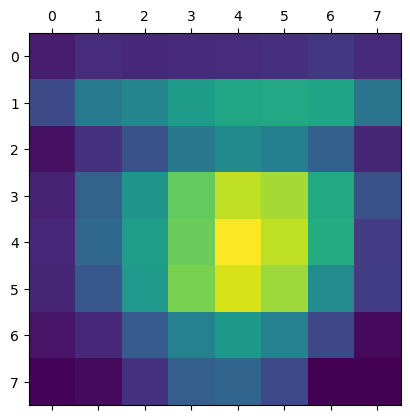

In [ ]:
# Remove last layer's softmax
model.layers[-1].activation = None

# Print what the top predicted class is
preds = model.predict(img)
print("Predicted:", preds)

# Generate class activation heatmap
heatmap = make_gradcam_heatmap(img, model, "conv5_block16_1_conv")
heatmap_2 = make_gradcam_heatmap(img, model, "conv5_block16_2_conv")
heatmap_3 = make_gradcam_heatmap(img, model, "conv5_block15_1_conv")
heatmap_4 = make_gradcam_heatmap(img, model, "conv5_block14_1_conv")
heatmap_5 = make_gradcam_heatmap(img, model, "conv5_block13_2_conv")

# Display heatmap
plt.matshow(heatmap)
plt.matshow(heatmap_2)
plt.matshow(heatmap_3)
plt.matshow(heatmap_4)
plt.matshow(heatmap_5)
plt.show()

# Grad-CAM Explains Why

The Grad-CAM technique utilizes the gradients of the classification score with respect to the final convolutional feature map, to identify the parts of an input image that most impact the classification score. The places where this gradient is large are exactly the places where the final score depends most on the data.

The gradCAM function computes the importance map by taking the derivative of the reduction layer output for a given class with respect to a convolutional feature map. For classification tasks, the gradCAM function automatically selects suitable layers to compute the importance map for. You can also specify the layers with the 'ReductionLayer' and 'FeatureLayer' name-value arguments.

 The 'jet' colormap has deep blue as the lowest value and deep red as the highest.

C:\Users\user\AppData\Local\Temp\ipykernel_9424\1896598370.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


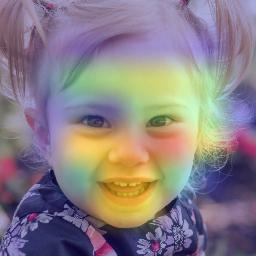

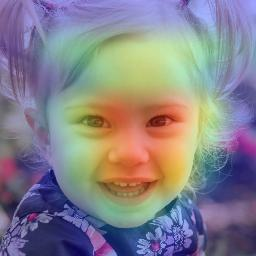

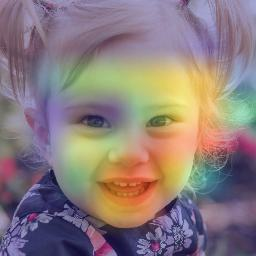

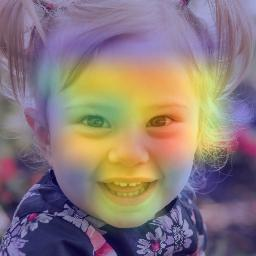

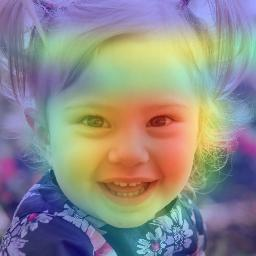

In [ ]:
save_and_display_gradcam(img_path, heatmap)
save_and_display_gradcam(img_path, heatmap_2)
save_and_display_gradcam(img_path, heatmap_3)
save_and_display_gradcam(img_path, heatmap_4)
save_and_display_gradcam(img_path, heatmap_5)

# CNN model architecture (Xception)

To be continued.

In [ ]:
#create the model's architecture and compile it
def get_xcp_model(input_shape):

    input = tf.keras.Input(shape=input_shape)

    xception = tf.keras.applications.Xception( weights="imagenet", include_top=False, input_tensor = input)

    x = tf.keras.layers.GlobalAveragePooling2D()(xception.output)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x) #binary classification

    model = tf.keras.Model(xception.input, output)

    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

    return model


In [ ]:
xcp_model = get_xcp_model(input_shape)

tf.keras.utils.plot_model(xcp_model, show_shapes=True)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
You must install pydot (`pip install pydot`) for `plot_model` to work.


In [ ]:
from pathlib import Path
import tensorflow as tf

# 체크포인트 저장 폴더 생성
checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(exist_ok=True)

# save_weights_only=True 이므로 .weights.h5로 끝나야 함
checkpoint_filepath_xcp = str(checkpoint_dir / "model_xcp.weights.h5")

checkpoint_xcp = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath_xcp,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True
)

early_stopping_xcp = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr_xcp = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

In [ ]:
history_ft = model_ft.fit(train_ds,
                       epochs = 10,
                       validation_data = valid_ds,
                       callbacks=[checkpoint_xcp, early_stopping_xcp, reduce_lr_xcp])

NameError: name 'model_ft' is not defined

# END :)